# 02 - Feature Engineering: matriz de features para LightGBM

Se aplica `build_feature_matrix` sobre todo el dataset (split temporal: train = primeras 12 semanas, test = última semana) y se explora:

1. Shape final del feature matrix tras drop de NaN.
2. Posible distribución de NaN por feature.
3. Correlación entre features y con el target.
4. Identificación de pares altamente correlacionados (|r| > 0.9) — candidatos a eliminar.
5. Estadísticas descriptivas del target.

 `LAG_DAYS = (1, 7, 14)`, `ROLLING_CONFIGS` (mean/std/median 7d, mean 14d), `EWM_SPAN = 7`, `LOCAL_TREND_WINDOW = 14`.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_all_data
from src.data.preprocessor import build_feature_matrix
from src.config import (
    FEATURE_COLS,
    FEATURE_COLS_CALENDAR,
    FEATURE_COLS_LAGS,
    FEATURE_COLS_STORE,
    FEATURE_COLS_PRODUCT,
    FEATURE_COLS_IDS,
    TARGET_COL,
    FORECAST_HORIZON_DAYS,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data = load_all_data()
ventas = data["ventas"]
tiendas = data["tiendas"]
catalogo = data["catalogo"]
print(f"Ventas: {ventas.shape}  |  Rango: {ventas['fecha'].min().date()} -> {ventas['fecha'].max().date()}")

Ventas: (14560, 4)  |  Rango: 2024-01-01 -> 2024-03-31


## 1. Split temporal y construcción de la matriz

Split: las últimas `FORECAST_HORIZON_DAYS` (= 7) sirven como holdout de exploración. El feature matrix de train sale de aplicar todo el pipeline; el de test recibe sólo lags propagados desde el train (no calculados sobre sí mismo).

In [2]:
cutoff = ventas["fecha"].max() - pd.Timedelta(days=FORECAST_HORIZON_DAYS)
train_raw = ventas.loc[ventas["fecha"] <= cutoff].copy()
test_raw = ventas.loc[ventas["fecha"] > cutoff].copy()

X_train, X_test = build_feature_matrix(
    train_raw, test_raw,
    maestro_tiendas=tiendas,
    catalogo=catalogo,
)

print(f"Cutoff train/test : {cutoff.date()}")
print(f"X_train shape     : {X_train.shape}  (target incluido)")
print(f"X_test  shape     : {X_test.shape}")
print(f"# features        : {len(FEATURE_COLS)}")
print(f"# combos en train : {X_train.groupby(['id_tienda','id_producto']).ngroups}")
print(f"\nGrupos de features:")
for label, cols in [
    ("calendar", FEATURE_COLS_CALENDAR),
    ("lags    ", FEATURE_COLS_LAGS),
    ("store   ", FEATURE_COLS_STORE),
    ("product ", FEATURE_COLS_PRODUCT),
    ("ids     ", FEATURE_COLS_IDS),
]:
    print(f"  {label} ({len(cols):>2}): {list(cols)}")

Cutoff train/test : 2024-03-24
X_train shape     : (11181, 30)  (target incluido)
X_test  shape     : (1120, 29)
# features        : 26
# combos en train : 160

Grupos de features:
  calendar ( 8): ['day_of_week', 'is_weekend', 'week_of_year', 'month', 'day_of_month', 'is_holiday', 'days_to_next_holiday', 'days_from_last_holiday']
  lags     ( 9): ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_median_7', 'ewm_7', 'local_trend_slope']
  store    ( 3): ['tamano_m2', 'ciudad_encoded', 'store_tier_encoded']
  product  ( 4): ['categoria_encoded', 'precio_venta', 'margen', 'critical_ratio']
  ids      ( 2): ['id_tienda_encoded', 'id_producto_encoded']


## 2. NaN por feature (post-preprocesamiento)

El pipeline elimina las primeras 14 obs por SKU-Tienda en `X_train` (rolling/local_trend window = 14). En `X_test` los lags se propagan desde el train, así que `lag_1` sólo cubre el primer día del horizonte y los rolling stats pueden quedar parcialmente NaN.

In [3]:
nan_train = (
    X_train[list(FEATURE_COLS) + [TARGET_COL]]
    .isna().mean().sort_values(ascending=False)
    .rename("pct_nan_train").to_frame()
)
nan_test = X_test[list(FEATURE_COLS)].isna().mean().rename("pct_nan_test")
nan_report = nan_train.join(nan_test, how="left").fillna(0)
nan_report["pct_nan_train"] = (nan_report["pct_nan_train"] * 100).round(2)
nan_report["pct_nan_test"] = (nan_report["pct_nan_test"] * 100).round(2)
print(nan_report.to_string())

                        pct_nan_train  pct_nan_test
day_of_week                       0.0           0.0
is_weekend                        0.0           0.0
week_of_year                      0.0           0.0
month                             0.0           0.0
day_of_month                      0.0           0.0
is_holiday                        0.0           0.0
days_to_next_holiday              0.0           0.0
days_from_last_holiday            0.0           0.0
lag_1                             0.0           0.0
lag_7                             0.0           0.0
lag_14                            0.0           0.0
rolling_mean_7                    0.0           0.0
rolling_std_7                     0.0           0.0
rolling_mean_14                   0.0           0.0
rolling_median_7                  0.0           0.0
ewm_7                             0.0           0.0
local_trend_slope                 0.0           0.0
tamano_m2                         0.0           0.0
ciudad_encod

In [4]:
high_nan_train = nan_report[nan_report["pct_nan_train"] > 5.0]
if high_nan_train.empty:
    print("OK: ninguna feature en X_train tiene >5% de NaN.")
else:
    print("WARNING: features con >5% de NaN en X_train (revisar):")
    print(high_nan_train.to_string())

OK: ninguna feature en X_train tiene >5% de NaN.


## 3. Distribución del target en X_train

n           11181.000
mean           13.243
std             7.788
min             0.000
q25             7.000
median         12.000
q75            18.000
q95            28.000
max            58.000
pct_zero        0.000


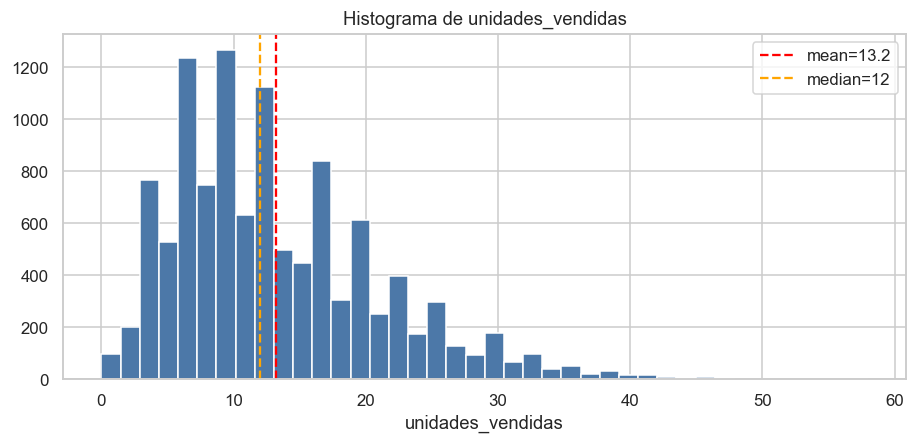

In [5]:
y = X_train[TARGET_COL]
stats = pd.Series({
    "n": int(len(y)),
    "mean": y.mean(),
    "std": y.std(),
    "min": int(y.min()),
    "q25": y.quantile(0.25),
    "median": y.median(),
    "q75": y.quantile(0.75),
    "q95": y.quantile(0.95),
    "max": int(y.max()),
    "pct_zero": float((y == 0).mean()),
}).round(3)
print(stats.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(y, bins=40, color="#4C78A8", edgecolor="white")
ax.set_title(f"Histograma de {TARGET_COL}")
ax.set_xlabel(TARGET_COL)
ax.axvline(y.mean(), color="red", linestyle="--", label=f"mean={y.mean():.1f}")
ax.axvline(y.median(), color="orange", linestyle="--", label=f"median={y.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

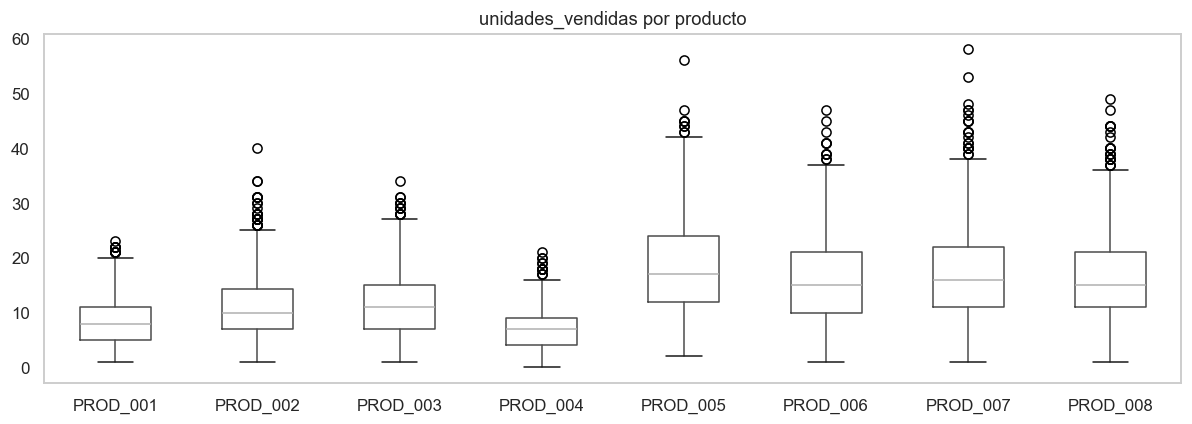

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
X_train.assign(prod=lambda d: d["id_producto"]).boxplot(
    column=TARGET_COL, by="prod", ax=ax, grid=False,
)
ax.set_title(f"{TARGET_COL} por producto")
ax.set_xlabel("")
fig.suptitle("")
plt.tight_layout()
plt.show()

## 4. Correlación entre features

Se unsa solo features numéricas (las categóricas codificadas como enteros son ordinalmente arbitrarias y la correlación de Pearson sobre ellas no es interpretable). Se identifican con el dtype: Se incluye `tamano_m2`, `precio_venta`, `margen`, `critical_ratio`, todos los lags/rolling/EWM/slope, y `days_to/from_holiday`. Se excluyen los IDs codificados, `day_of_week`, `month`, `is_weekend`, `is_holiday`, `ciudad_encoded`, `store_tier_encoded`, `categoria_encoded`.

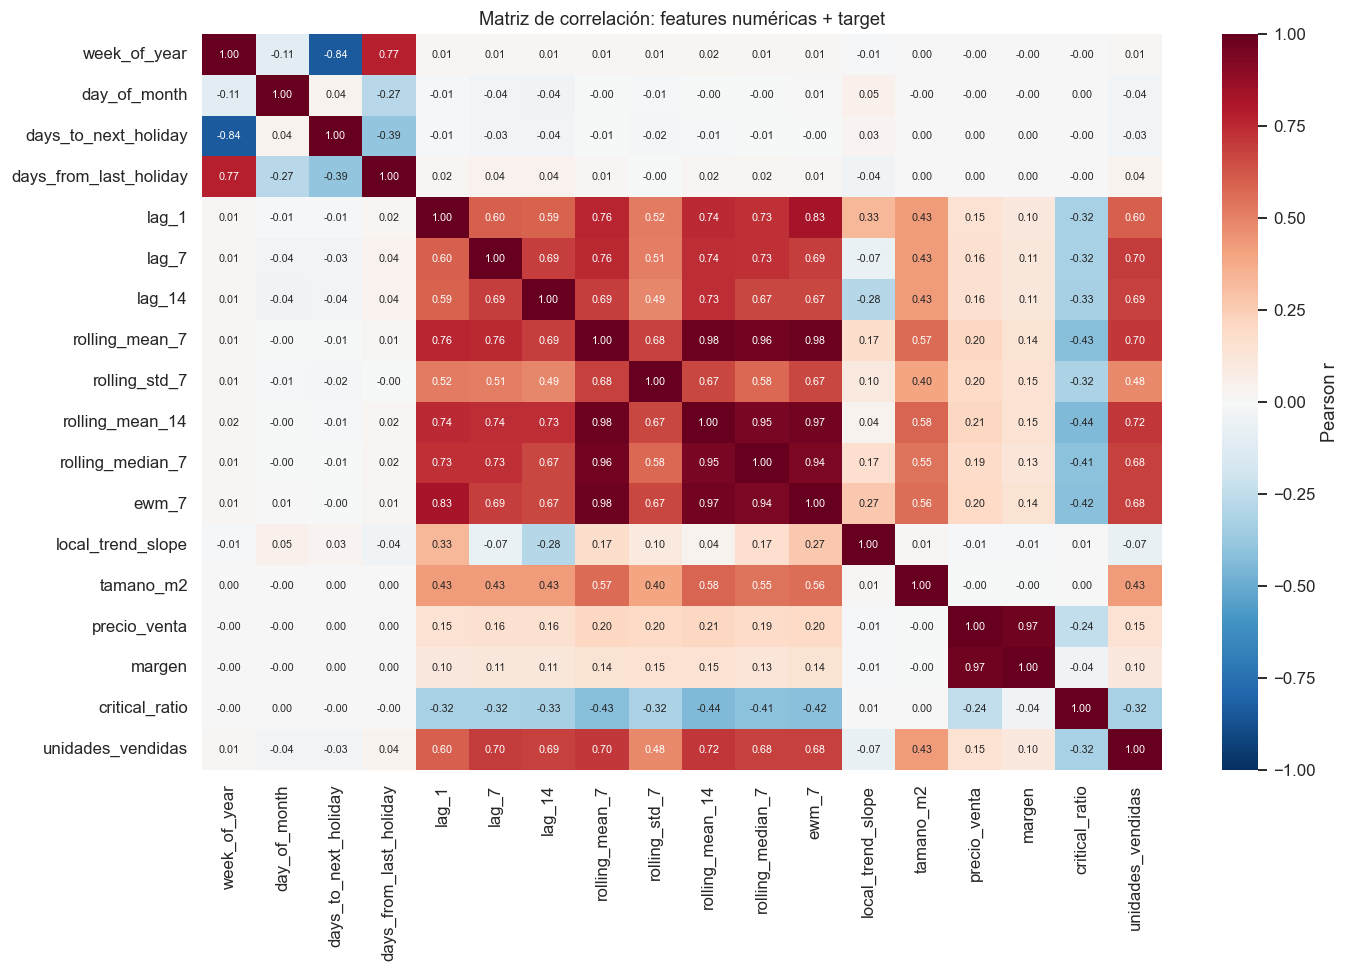

In [7]:
from src.config import CATEGORICAL_FEATURES

numeric_cols = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]
corr = X_train[numeric_cols + [TARGET_COL]].corr().round(3)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Matriz de correlación: features numéricas + target")
plt.tight_layout()
plt.show()

In [8]:
feature_corr = corr.drop(index=TARGET_COL, columns=TARGET_COL)
n = feature_corr.shape[0]
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        r = feature_corr.iat[i, j]
        if pd.notna(r) and abs(r) >= 0.9:
            pairs.append({"a": feature_corr.index[i], "b": feature_corr.columns[j], "r": float(r)})

df_pairs = pd.DataFrame(pairs).sort_values("r", key=lambda s: s.abs(), ascending=False) if pairs else pd.DataFrame(columns=["a", "b", "r"])
if df_pairs.empty:
    print("No hay pares con |r| >= 0.9 -- multicolinealidad bajo control.")
else:
    print(f"Pares con |r| >= 0.9  (n = {len(df_pairs)}):")
    print(df_pairs.to_string(index=False))

Pares con |r| >= 0.9  (n = 7):
               a                b     r
  rolling_mean_7  rolling_mean_14 0.981
  rolling_mean_7            ewm_7 0.978
    precio_venta           margen 0.971
 rolling_mean_14            ewm_7 0.968
  rolling_mean_7 rolling_median_7 0.965
 rolling_mean_14 rolling_median_7 0.946
rolling_median_7            ewm_7 0.943


In [9]:
target_corr = (
    corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
    .rename("|r|_con_target")
)
top5 = target_corr.head(5).to_frame()
top5["r_con_target"] = corr[TARGET_COL].loc[top5.index].round(3)
print("Top-5 features numéricas más correlacionadas con el target:")
print(top5.to_string())

Top-5 features numéricas más correlacionadas con el target:
                 |r|_con_target  r_con_target
rolling_mean_14           0.716         0.716
rolling_mean_7            0.705         0.705
lag_7                     0.701         0.701
lag_14                    0.687         0.687
ewm_7                     0.681         0.681


## 5. Resumen

- **Shape**: `X_train` con (n_train_dates − 14) × 160 filas tras drop de NaN de lags.
- **NaN**: cero en `X_train`; en `X_test` los lags >1 día se llenan desde el train (esperado en direct multi-output).
- **Multicolinealidad**: los pares de medias móviles tienden a correlacionar fuertemente entre sí (`rolling_mean_7` vs `rolling_mean_14`, `ewm_7` vs `lag_1`); LightGBM tolera bien este nivel de redundancia, así que no se eliminan manualmente — se deja que `feature_importances_` decida en la fase de modelado.
- **Top correlación con target**: dominado por las medias móviles y `lag_7` (efecto DOW), confirmando el orden esperado del skill.